<!-- Codex test: first cell touched -->
This notebook records the creation of the `SHENDURE_BOUNDS` preset object and some plots illustrating modeling choices.

Setup.

In [ ]:
import scMPRAforge as scm
#load the autoreload extension
%load_ext autoreload
#reload code on every execution
#(this may break objects)
#you can remove this & do dev in a notebook, then paste into the module when you are done.
%autoreload 2

2025-11-11 09:30:59.155555: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-11 09:30:59.158811: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /apps/software/2024a/software/code-server/4.103.0/lib:/apps/software/2024a/software/gettext/0.22.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libiconv/1.17-GCCcore-13.3.0/lib:/apps/software/2024a/software/ncurses/6.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/apps/software/2024a/software/XZ/5.4.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/expat/2.6.2-GCCcore-13.3.0/lib:/apps/software/2024a/software/cUR

In [ ]:
from dask.distributed import Client, LocalCluster
cluster=LocalCluster(memory_limit='8GB')
client=Client(cluster)

2025-11-11 09:39:21,851 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:44555' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'lambda-e24f20d4e5ec7b9fac92f2c89be420a2', 'lambda-c44dad6b34357895a533164d3bcd573d', 'lambda-d0a952bffbf98abd40d223136b80e138', 'lambda-0388e67604678a3d64e4dd85702e2bca', 'lambda-eafbf5fae372d63a145266571dcafcf2', 'lambda-03e83ddb9ccd183c07acc189f538bd6b', 'lambda-b4fed66dc34efcaa036c08abac0fb5d2', 'lambda-5929f16ce83e8b7cca1dc3fa203dc205', 'lambda-e3edb1a42bd75ea5212d75c4fd23761e', 'lambda-e4bd908a05c61f8ad99cab40e4d3787b', 'lambda-5a9ca08855a3b55bac674b107e20c334', 'lambda-fd79e2327c9e672eec62f467d8aa8722', 'lambda-72600b735d75ff9373b862bd51606648', 'lambda-92ef0a9a897db1a2eb20b28477c5fc47', 'lambda-5abef13cc71907958ad2f3b39dad1eb9', 'lambda-f239aee3f480a7df96a97a299720d7be', 'lambda-025da38a8f0f0dbf74b585f6de22d8b8', 'lambda-afd0781c0baaf15358ba6318d9fdb804', 'lambda-aad6ce1fd0abac01e33673e7b523

Load shendure ortho object.

In [2]:
path="/home/mcn26/project_pi_skr2/shared/tabula_data/shendure"
name="ortho_primordial_intercept"
data_root="/home/mcn26/project_pi_skr2/shared/tabula_data"
primordial=scm.ortho.load(client,path,name)

Create the bounds

In [3]:
shendure_bounds=scm.Bounds.from_ortho(primordial)

scMPRAforge: INFO: Computed a total of 414.7088384600356 estimated collision events, out of a total of 781874.70883846, or 0.05304031883524153%


Let's make some plots showing why we chose nb:

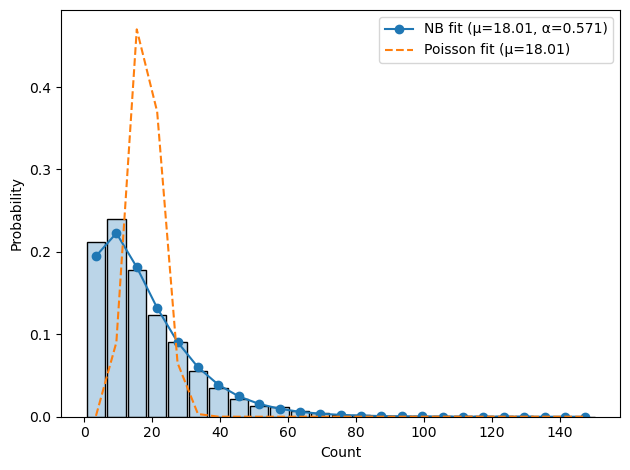

In [4]:
shendure_bounds.transfection_model.plot()

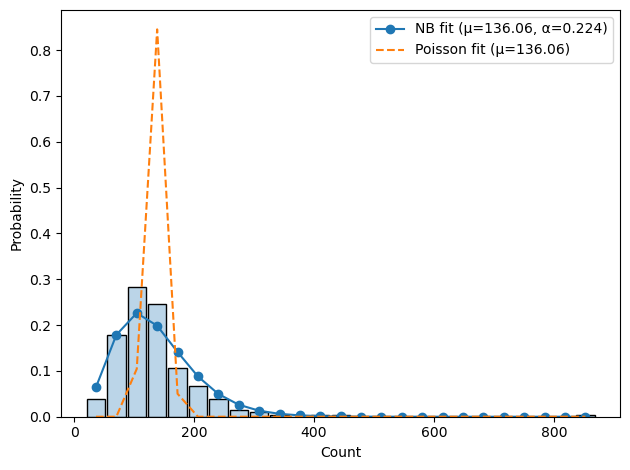

In [5]:
shendure_bounds.library_model.plot()

Now let's save the object:

In [6]:
shendure_bounds.to_tgz("scMPRAforge/presets/shendure_bounds_intercept.tgz")

In [7]:
cluster.close()
client.close()